# Elastic FFT Homogenization — Newton-CG in JAX

Solves the linear elastic micro-mechanical equilibrium on a periodic RVE using
the DBFFT / Newton-CG scheme from FFTMAD, translated into JAX.

**Problem**: find the strain field $\boldsymbol{\varepsilon}(\mathbf{x})$ on a
heterogeneous RVE $Y$ such that
$$\nabla \cdot \boldsymbol{\sigma} = \mathbf{0}, \quad
\boldsymbol{\sigma} = \mathbb{C}(\mathbf{x}):\boldsymbol{\varepsilon}, \quad
\langle\boldsymbol{\varepsilon}\rangle = \bar{\boldsymbol{\varepsilon}}$$

**Solver**: one Newton step (exact for linear elasticity) → CG solves the
matrix-free Lippmann–Schwinger system
$$A(\delta\boldsymbol{\varepsilon}) = \mathbf{b}, \qquad
A(\delta\boldsymbol{\varepsilon}) =
\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\mathbb{C}:\delta\boldsymbol{\varepsilon}]\bigr]$$

In [17]:
import sys
sys.path.insert(0, '../src')

import jax
import jax.numpy as jnp
from jax import jit
from jax.scipy.sparse.linalg import cg as jax_cg
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from generation.rve                import make_square_composite_rve
from mat_models.elastic            import LinearElasticIsotropic, assemble_C_field
from operators.green               import build_freq_grid, build_green_operator
from operators.general_functions   import ddot42
from post.fields                   import field_to_grid, von_mises, compute_displacement
from post.io                       import IncrementalWriter, to_voigt

jax.config.update('jax_enable_x64', True)
print('JAX', jax.__version__, '|', jax.default_backend(), '|', jax.devices())

JAX 0.9.0.1 | cpu | [CpuDevice(id=0)]


## 1  Microstructure — 2-Phase Composite

Circular stiff inclusion (steel-like) in a soft matrix (aluminium-like).

LinearElasticIsotropic (epoxy matrix): E=3.5e+03, nu=0.35, lam=3.02e+03, mu=1.3e+03
LinearElasticIsotropic (carbon fibre): E=2.8e+04, nu=0.23, lam=9.7e+03, mu=1.14e+04


$r = 3.5\,\mu\mathrm{m}$ &emsp;|&emsp; $L = 11.33\,\mu\mathrm{m}$ &emsp;|&emsp; Target $\phi = 0.600$ &emsp;|&emsp; Actual $\phi = 0.600$ &emsp;|&emsp; $N = 114$, $n_z = 1$ &emsp;|&emsp; 0.100 µm/px

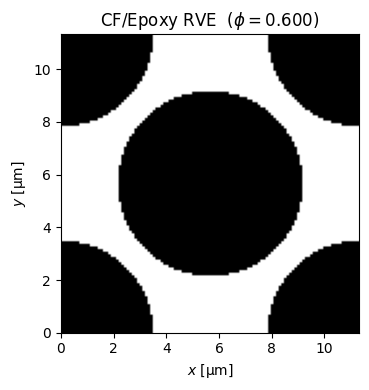

In [18]:
# ── RVE parameters ────────────────────────────────────────────────────────────
phi      = 0.6      # target fibre volume fraction
r_fib_um = 3.5      # fibre radius [µm]
vox_um   = 0.1      # physical voxel size [µm/px]
nz       = 1        # voxels through the thickness (nz=1 → 2-D plane-strain)

# ── Materials ─────────────────────────────────────────────────────────────────
materials = [
    LinearElasticIsotropic(E=3.5e3, nu=0.35, name='epoxy matrix'),
    LinearElasticIsotropic(E=28e3,  nu=0.23, name='carbon fibre'),
]
for m in materials:
    print(m)

# ── Generate RVE ──────────────────────────────────────────────────────────────
phase_np, N, n, L, phi_ = make_square_composite_rve(phi, r_fib_um, vox_um, nz=nz)
N_vox  = int(np.prod(n))
phase  = jnp.array(phase_np.ravel())

# Per-voxel stiffness field  (3,3,3,3,Nv)
C_field = assemble_C_field(materials, phase)

# Reference medium: volume-fraction (Voigt) average of Lamé constants
lam0 = phi_ * materials[1].lam + (1 - phi_) * materials[0].lam
mu0  = phi_ * materials[1].mu  + (1 - phi_) * materials[0].mu

display(Markdown(
    f'$r = {r_fib_um}\\,\\mu\\mathrm{{m}}$'
    f' &emsp;|&emsp; $L = {L[0]:.2f}\\,\\mu\\mathrm{{m}}$'
    f' &emsp;|&emsp; Target $\\phi = {phi:.3f}$'
    f' &emsp;|&emsp; Actual $\\phi = {phi_:.3f}$'
    f' &emsp;|&emsp; $N = {N}$, $n_z = {nz}$'
    f' &emsp;|&emsp; {vox_um:.3f} µm/px'
))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(phase_np[:, :, 0].T, origin='lower', cmap='gray_r',
          extent=[0, L[0], 0, L[1]])
ax.set_title(f'CF/Epoxy RVE  ($\\phi = {phi_:.3f}$)')
ax.set_xlabel('$x$ [µm]');  ax.set_ylabel('$y$ [µm]')
ax.set_aspect('equal')
plt.tight_layout();  plt.show()

## 2  Core Operators

In [19]:
# fft_s / ifft_s close over the global n — used in the verification cell.
# The solver uses its own local FFT helpers (independent of global n).

@jit
def fft_s(x):
    """FFT over spatial dims only. Reshapes (..., Nv) → (..., *n) before transform."""
    shape = x.shape
    return jnp.fft.fftn(x.reshape(shape[:-1] + n), axes=(-3, -2, -1)).reshape(shape)

@jit
def ifft_s(x):
    """Inverse FFT over spatial dims only."""
    shape = x.shape
    return jnp.fft.ifftn(x.reshape(shape[:-1] + n), axes=(-3, -2, -1)).real.reshape(shape)

print(f'Reference medium: λ₀={lam0/1e3:.1f} GPa  μ₀={mu0/1e3:.1f} GPa')

Reference medium: λ₀=7.0 GPa  μ₀=7.3 GPa


## 3  Green's Operator $\hat{\boldsymbol{\Gamma}}_0(\boldsymbol{\xi})$

$$K^{-1}_{ij}(\boldsymbol{\xi}) = \frac{1}{\mu_0|\boldsymbol{\xi}|^2}
\!\left(\delta_{ij} - \frac{\lambda_0+\mu_0}{\lambda_0+2\mu_0}\hat{n}_i\hat{n}_j\right)
\qquad
\hat{\Gamma}_{0,ijkl} = -\tfrac{1}{4}\bigl(
K^{-1}_{ik}\hat{n}_j\hat{n}_l + \text{3 sym. terms}\bigr)$$

In [20]:
xi_flat = build_freq_grid(n, L)                     # (3, Nv)
xi_sq   = jnp.sum(xi_flat**2, axis=0)              # (Nv,) — used in verification
G_glob  = build_green_operator(xi_flat, lam0, mu0)  # (3,3,3,3,Nv)
dx      = tuple(float(Li / ni) for Li, ni in zip(L, n))
print('G_glob shape:', G_glob.shape)

G_glob shape: (3, 3, 3, 3, 12996)


## 4  Newton-CG Solve

For **linear elasticity**, Newton converges in **one step**.
The single CG system is:

$$A(\delta\boldsymbol{\varepsilon}) = \mathbf{b}$$

$$A(\delta\boldsymbol{\varepsilon}) =
\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\mathbb{C}(\mathbf{x}):\delta\boldsymbol{\varepsilon}]\bigr]$$

$$\mathbf{b} = -\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\boldsymbol{\sigma}^{(0)} - \boldsymbol{\sigma}^\text{goal}]\bigr]$$

with initial guess $\boldsymbol{\varepsilon}^{(0)} = \bar{\boldsymbol{\varepsilon}}$
(uniform strain) and $\boldsymbol{\sigma}^\text{goal} = \mathbf{0}$.

`solve_elastic` carries out the full Newton-CG step in five stages:

**1. Local FFT helpers** — `fft_` / `ifft_`  
The global helpers `fft_s`/`ifft_s` close over the global `n`, so they cannot be used inside a JIT-compiled function that must work for arbitrary grid shapes.  
`fft_` and `ifft_` are re-defined locally, capturing `n_i` (a *static* argument) via a default-argument trick so JAX can trace through them without retracing on every call.

**2. Matrix-free operator** — `A_op`  
Implements the Lippmann–Schwinger operator as a flat-vector → flat-vector map
$$A(v) = \mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 : \mathcal{F}[\mathbb{C}:v]\bigr]$$
required by `jax.scipy.sparse.linalg.cg`.  The closed-over arrays (`C_field`, `G_glob`) are baked in via default args so JAX traces them as constants.

**3. Initial field and stress** — `eps0`, `sigma0`  
The uniform guess $\boldsymbol{\varepsilon}^{(0)} = \bar{\boldsymbol{\varepsilon}}$ is broadcast over all $N_v$ voxels.  
The corresponding stress $\boldsymbol{\sigma}^{(0)} = \mathbb{C}:\boldsymbol{\varepsilon}^{(0)}$ is the starting residual.

**4. Right-hand side** — `bb`  
$$\mathbf{b} = -\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 : \mathcal{F}[\boldsymbol{\sigma}^{(0)} - \boldsymbol{\sigma}^\text{goal}]\bigr]$$
For the default `stress_goal = 0` this simplifies to projecting the initial stress residual into the compatible–equilibrated subspace.  A non-zero `stress_goal` shifts the target (used for mixed boundary conditions).

**5. CG solve and update**  
`jax_cg` finds the zero-mean fluctuation $\delta\boldsymbol{\varepsilon}$ such that $A(\delta\boldsymbol{\varepsilon})=\mathbf{b}$.  
For **linear** elasticity Newton converges in one step, so CG is solving the exact system.  
The final fields are
$$\boldsymbol{\varepsilon} = \boldsymbol{\varepsilon}^{(0)} + \delta\boldsymbol{\varepsilon}, \qquad \boldsymbol{\sigma} = \mathbb{C}:\boldsymbol{\varepsilon}$$
`info` is `None` on convergence or an integer iteration count if the tolerance was not reached.


In [21]:
@partial(jit, static_argnames=('n_i', 'maxiter'))
def solve_elastic(n_i, C_field, G_glob, eps_bar,
                  stress_goal=None, toler_lin=1e-10, maxiter=1000):
    """
    JIT-compiled elastic FFT solve.  Recompiles per unique n_i (shape-cached).

    n_i         : tuple (static)    grid shape, e.g. (64, 64, 1)
    C_field     : (3,3,3,3,Nv)      per-voxel stiffness
    G_glob      : (3,3,3,3,Nv)      Green\'s operator
    eps_bar     : (3,3)             prescribed macroscopic strain
    stress_goal : (3,3,Nv) | None  target voxel stress  (default 0)
    """
    Nv = int(np.prod(n_i))

    def fft_(x, _n=n_i): 
        s=x.shape; 
        return jnp.fft.fftn( x.reshape(s[:-1]+_n),axes=(-3,-2,-1)).reshape(s)
    
    def ifft_(x, _n=n_i): 
        s=x.shape; 
        return jnp.fft.ifftn(x.reshape(s[:-1]+_n),axes=(-3,-2,-1)).real.reshape(s)

    def A_op(v_flat, _C=C_field, _G=G_glob, _Nv=Nv, _f=fft_, _if=ifft_):
        v = v_flat.reshape(3, 3, _Nv)
        return _if(jnp.einsum('ijklm,klm->ijm', _G,
                   _f(jnp.einsum('ijklm,klm->ijm', _C, v)))).reshape(-1)

    sg     = jnp.zeros((3, 3, Nv)) if stress_goal is None else stress_goal
    eps0   = jnp.ones((3, 3, Nv)) * eps_bar[:, :, None]
    sigma0 = jnp.einsum('ijklm,klm->ijm', C_field, eps0)
    bb     = -ifft_(jnp.einsum('ijklm,klm->ijm', G_glob, fft_(sigma0 - sg))).reshape(-1)

    delta, info = jax_cg(A_op, bb, tol=toler_lin, maxiter=maxiter)
    eps   = eps0 + delta.reshape(3, 3, Nv)
    sigma = jnp.einsum('ijklm,klm->ijm', C_field, eps)
    return eps, sigma, info

print('Functions defined.  solve_elastic(n_i, C_field, G_glob, eps_bar, ...)')


Functions defined.  solve_elastic(n_i, C_field, G_glob, eps_bar, ...)


## 4b  Mixed Stress/Strain Control (experimental)

For components where a **macro-stress** is prescribed instead of a macro-strain,
the standard strain-controlled CG solve cannot be used directly.

FFTMAD (Lucarini & Segurado 2018) encodes this via a DC-mode modification of $\hat{\boldsymbol{\Gamma}}_0$.
That trick works inside their Newton loop because the initial guess is always warm (close to the solution),
so CG needs very few steps and the fact that the modified operator is not strictly SPD does not matter.
For a cold-start JAX solve the same modification causes CG to diverge.

**JAX version — outer macro-strain correction loop:**
Keep the inner CG solver unchanged; add an outer loop that iteratively corrects
the macroscopic strain for the stress-controlled components:

$$\bar{\boldsymbol{\varepsilon}}^{S,k+1} = \bar{\boldsymbol{\varepsilon}}^{S,k}
- \mathbb{S}_0^{SS}:\bigl(\bar{\boldsymbol{\sigma}}^{S,k}-\bar{\boldsymbol{\sigma}}^{S,\text{goal}}\bigr)$$

where $\mathbb{S}_0 = \text{pinv}(\langle\mathbb{C}\rangle)$ (Voigt compliance as preconditioner).
For linear elasticity this converges in a handful of outer iterations.


In [15]:
def solve_mixed(n_i, C_field, G_glob, eps_bar, stress_mask,
                stress_goal=None, toler=1e-8, maxiter_outer=50,
                toler_lin=1e-10, maxiter_lin=1000):
    """
    Mixed stress/strain FFT solve — outer macro-strain correction loop.

    eps_bar     : (3,3)  prescribed macro-strain for kinematic components
    stress_mask : (3,3)  1 = stress prescribed (target stress_goal), 0 = strain prescribed
    stress_goal : (3,3)  target macro-stress for masked components (default 0)
    """
    sg   = jnp.zeros((3, 3)) if stress_goal is None else stress_goal
    mask = stress_mask.astype(bool)

    # Voigt compliance as preconditioner — pinv handles the null space of the 9x9
    # (C_ijkl maps anti-symmetric inputs to 0, so the 9x9 reshape is singular)
    C_voigt = jnp.mean(C_field, axis=-1)                             # (3,3,3,3)
    S_voigt = jnp.linalg.pinv(C_voigt.reshape(9, 9)).reshape(3, 3, 3, 3)

    # Kinematic components fixed; stress-controlled start at 0
    eps_k = jnp.where(mask, 0.0, eps_bar)

    for it in range(maxiter_outer):
        eps, sigma, info = solve_elastic(n_i, C_field, G_glob, eps_k,
                                         toler_lin=toler_lin, maxiter=maxiter_lin)
        sigma_bar  = jnp.mean(sigma, axis=-1)                        # (3,3)
        stress_res = jnp.where(mask, sigma_bar - sg, 0.0)

        if float(jnp.max(jnp.abs(stress_res))) < toler:
            break

        correction = jnp.einsum('ijkl,kl->ij', S_voigt, stress_res)
        eps_k      = eps_k - jnp.where(mask, correction, 0.0)

    return eps, sigma, info


print('solve_mixed defined')


solve_mixed defined


In [ ]:
# ── Uniaxial stress in e22: prescribe ε̄₂₂, leave σ̄₁₁ = 0 free ──────────
eps_bar_22   = jnp.zeros((3, 3)).at[1, 1].set(1e-3)   # ε̄₂₂ = 1e-3
stress_mask_11 = jnp.zeros((3, 3)).at[0, 0].set(1)    # σ̄₁₁ prescribed to 0

eps_m, sigma_m, info_m = solve_mixed(n, C_field, G_glob,
                                       eps_bar_22, stress_mask_11)

sigma_bar_m = jnp.mean(sigma_m, axis=-1)
eps_bar_m   = jnp.mean(eps_m,   axis=-1)
E22_eff     = float(sigma_bar_m[1, 1]) / float(eps_bar_m[1, 1])

print(f'Macro strain   ε̄₁₁={eps_bar_m[0,0]:.4e}  ε̄₂₂={eps_bar_m[1,1]:.4e}')
print(f'Macro stress   σ̄₁₁={sigma_bar_m[0,0]:.4e}  σ̄₂₂={sigma_bar_m[1,1]:.4e}')
print(f'E22_eff = {E22_eff/1e3:.3f} GPa  (uniaxial stress σ̄₁₁=0, ε̄₂₂ driven)')


## 5  Run — Uniaxial Tension $\bar{\varepsilon}_{11} = 1.0 \times 10^{-3}$

The macroscopic strain $\bar{\boldsymbol{\varepsilon}}$ enters as an **initial uniform field**
$\boldsymbol{\varepsilon}^{(0)}(\mathbf{x}) = \bar{\boldsymbol{\varepsilon}}$, which trivially satisfies
$\langle\boldsymbol{\varepsilon}\rangle = \bar{\boldsymbol{\varepsilon}}$ by construction.

The CG system then finds a **fluctuation correction** $\delta\boldsymbol{\varepsilon}$
such that the total field $\boldsymbol{\varepsilon} = \boldsymbol{\varepsilon}^{(0)} + \delta\boldsymbol{\varepsilon}$
is mechanically compatible and in equilibrium:

$$A(\delta\boldsymbol{\varepsilon}) = \mathbf{b}, \qquad
\mathbf{b} = -\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\mathbb{C}:\boldsymbol{\varepsilon}^{(0)}]\bigr]$$

The mean of the correction is **automatically zero** because $\hat{\boldsymbol{\Gamma}}_0(\boldsymbol{\xi}=\mathbf{0}) = 0$
(the DC mode of the Green's operator vanishes by construction).
Any $\delta\boldsymbol{\varepsilon}$ produced by CG therefore has zero spatial mean,
so the macroscopic constraint $\langle\boldsymbol{\varepsilon}\rangle = \bar{\boldsymbol{\varepsilon}}$
is preserved exactly throughout the iteration — no Lagrange multiplier or projection step is needed.


In [22]:
import time

eps_bar     = jnp.zeros((3, 3)).at[1, 1].set(1e-3)
stress_goal = jnp.zeros((3, 3, N_vox))

print('Tracing...')
t0 = time.perf_counter()
eps, sigma, info = solve_elastic(n, C_field, G_glob, eps_bar, stress_goal)
jax.block_until_ready((eps, sigma))
t_compile = time.perf_counter() - t0

t0 = time.perf_counter()
eps, sigma, info = solve_elastic(n, C_field, G_glob, eps_bar, stress_goal)
jax.block_until_ready((eps, sigma))
t_run = time.perf_counter() - t0

print(f'Compile: {t_compile:.3f}s  |  Run: {t_run*1000:.2f}ms  |  CG info: {info}')
print(eps.mean(axis=-1))
print(sigma.mean(axis=-1))


Tracing...
Compile: 0.887s  |  Run: 769.49ms  |  CG info: None
[[ 8.70298327e-19 -1.21935203e-19  0.00000000e+00]
 [-1.07262267e-18  1.00000000e-03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]
[[ 6.06151914e+00 -4.95699232e-05  0.00000000e+00]
 [-4.95699232e-05  1.20458317e+01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.90883686e+00]]


## 6  Verification

In [23]:
# --- mean strain matches prescribed ---
eps_mean = jnp.mean(eps, axis=-1)
print('Mean strain error:', float(jnp.max(jnp.abs(eps_mean - eps_bar))))

# --- stress equilibrium: ∇·σ ≈ 0 ---
sigma_ft  = fft_s(sigma)
div_sigma = jnp.zeros((3, N_vox), dtype=complex)
for i in range(3):
    for j in range(3):
        div_sigma = div_sigma.at[i].add(1j * xi_flat[j] * sigma_ft[i, j])
div_real  = jnp.fft.ifftn(div_sigma.reshape(3, *n), axes=(-3, -2, -1)).real

sigma_ref = float(jnp.linalg.norm(jnp.mean(sigma, axis=-1)))
equil_err = float(jnp.linalg.norm(div_real)) / (sigma_ref * N_vox**0.5)
print(f'Equilibrium residual: {equil_err:.2e}  (should be < tol)')

# --- macroscopic C₁₁₁₁_eff ---
sigma_bar = jnp.mean(sigma, axis=-1)
C1111_eff = float(sigma_bar[1, 1]) / float(eps_bar[1, 1])

# --- Schürmann semi-empirical E₂ (transverse Young's modulus, uniaxial stress) ---
Em_ps   = materials[0].E / (1 - materials[0].nu**2)
E2_semi = (Em_ps * (1 + 0.85*phi_**2)
           / ((1 - phi_)**1.25 + Em_ps / materials[1].E * phi_))
rel_err = (C1111_eff - E2_semi) / C1111_eff * 100

display(Markdown(f"""
| Quantity | Value |
|---|---|
| FFT $C_{{1111}}^{{\\rm eff}}$ (uniaxial strain) | **{C1111_eff/1e3:.2f} GPa** |
| Schürmann $E_\\perp$ (uniaxial stress) | **{E2_semi/1e3:.2f} GPa** |
| Relative error $(C_{{1111}} - E_\\perp)/C_{{1111}}$ | **{rel_err:.1f} %** |
"""))

Mean strain error: 1.7564075194265172e-17
Equilibrium residual: 6.26e-09  (should be < tol)



| Quantity | Value |
|---|---|
| FFT $C_{1111}^{\rm eff}$ (uniaxial strain) | **12.05 GPa** |
| Schürmann $E_\perp$ (uniaxial stress) | **12.91 GPa** |
| Relative error $(C_{1111} - E_\perp)/C_{1111}$ | **-7.2 %** |


## 7  Field Plots

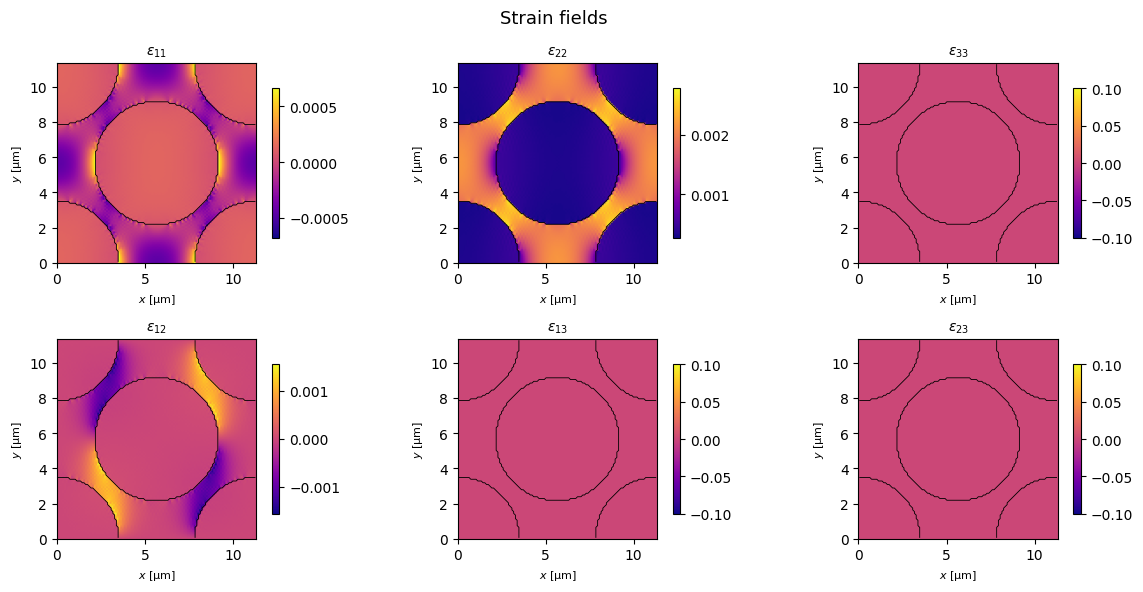

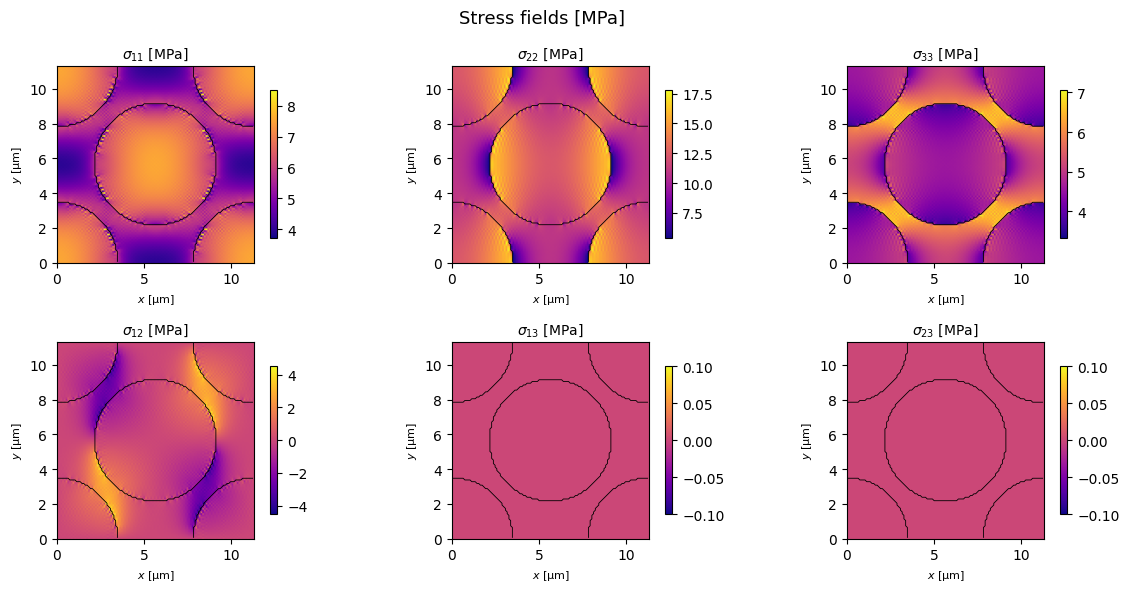

In [24]:
def field2d(arr_flat, component, title, ax, cmap='RdBu_r'):
    """Plot one tensor component on a given Axes."""
    i, j = component
    data = np.array(arr_flat[i, j, :].reshape(N, N))
    im = ax.imshow(data.T, origin='lower', cmap=cmap,
                   extent=[0, L[0], 0, L[1]])
    ax.contour(phase_np[:, :, 0].T, levels=[0.5], colors='k',
               linewidths=0.6, origin='lower', extent=[0, L[0], 0, L[1]])
    plt.colorbar(im, ax=ax, shrink=0.75)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$ [µm]', fontsize=8)
    ax.set_ylabel('$y$ [µm]', fontsize=8)
    ax.set_aspect('equal')

# symmetric tensor components in Voigt order (normal first, then shear)
strain_comps = [
    ((0,0), r'$\varepsilon_{11}$'), ((1,1), r'$\varepsilon_{22}$'), ((2,2), r'$\varepsilon_{33}$'),
    ((0,1), r'$\varepsilon_{12}$'), ((0,2), r'$\varepsilon_{13}$'), ((1,2), r'$\varepsilon_{23}$'),
]
stress_comps = [
    ((0,0), r'$\sigma_{11}$ [MPa]'), ((1,1), r'$\sigma_{22}$ [MPa]'), ((2,2), r'$\sigma_{33}$ [MPa]'),
    ((0,1), r'$\sigma_{12}$ [MPa]'), ((0,2), r'$\sigma_{13}$ [MPa]'), ((1,2), r'$\sigma_{23}$ [MPa]'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (comp, title) in zip(axes.ravel(), strain_comps):
    field2d(eps, comp, title, ax, cmap='plasma')
fig.suptitle('Strain fields', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (comp, title) in zip(axes.ravel(), stress_comps):
    field2d(sigma, comp, title, ax, cmap='plasma')
fig.suptitle('Stress fields [MPa]', fontsize=13)
plt.tight_layout()
plt.show()


## 8  Load Stepping — Stress–Strain Curve + ParaView Export

Prescribe increasing $\bar{\varepsilon}_{11}$, record $\bar{\sigma}_{11}$, and write
each increment to HDF5 + XDMF in one pass.
Open `output/rve_loadsteps.xdmf` with the **Xdmf3ReaderT** reader in ParaView.

In [26]:
# ── Load-step parameters ──────────────────────────────────────────────────────
# Target macroscopic strain tensor — edit components to change the loading mode
eps_goal = jnp.array([
    [0.0, 1.e-3,  0.0],
    [1.e-3,  0.0,  0.0],
    [0.0,  0.0,  0.0],
])  # uniaxial tension in x  (ε̄₁₁ = 5×10⁻³ at t = 1)

n_steps = 10
t_max   = 1.0
times   = np.linspace(0.0, t_max, n_steps + 1)[1:]   # (0, t_max]

# ── Combined loop: solve → record C₁₁₁₁ → write ParaView increment ───────────

with IncrementalWriter("output/rve_loadsteps", grid_shape=n, grid_spacing=dx) as w:
    for step, t in enumerate(times):
        eps_bar_i = float(t) * eps_goal
        eps_i, sigma_i, _ = solve_elastic(n, C_field, G_glob, eps_bar_i)

        e11_val      = float(eps_bar_i[0, 0])
        sigma_bar_11 = float(jnp.mean(sigma_i[0, 0, :]))


        eps_grid   = field_to_grid(eps_i,   n)
        sigma_grid = field_to_grid(sigma_i, n)
        u_grid     = compute_displacement(eps_i, eps_bar_i, xi_flat, n, dx)

        w.write_increment(step, {
            "phase":        phase_np.astype(np.float32),
            "displacement": u_grid.astype(np.float64),
            "strain":       to_voigt(eps_grid).astype(np.float64),
            "stress":       to_voigt(sigma_grid).astype(np.float64),
            "von_mises":    von_mises(sigma_grid).astype(np.float64),
        }, time=float(t))

        print(f"  step {step+1:2d}/{n_steps}  t={t:.2f}  ")

print(f"\nWritten → output/rve_loadsteps.h5 + output/rve_loadsteps.xdmf")





# fig, ax = plt.subplots(figsize=(5, 4))
# ax.plot([e * 100 for e in eps_11_vals], sig_11_vals,
#         'o-', label=r'FFT $C_{1111}^{\rm eff}$')
# ax.set_xlabel(r'$\bar{\varepsilon}_{11}$ [%]')
# ax.set_ylabel(r'$\bar{\sigma}_{11}$ [MPa]')
# ax.set_title(f'Macroscopic stress–strain  (φ={phi_:.3f},  nz={nz})')
# ax.legend();  ax.grid(True, alpha=0.3)
# plt.tight_layout();  plt.show()

  step  1/10  t=0.10  
  step  2/10  t=0.20  
  step  3/10  t=0.30  
  step  4/10  t=0.40  
  step  5/10  t=0.50  
  step  6/10  t=0.60  
  step  7/10  t=0.70  
  step  8/10  t=0.80  
  step  9/10  t=0.90  
  step 10/10  t=1.00  

Written → output/rve_loadsteps.h5 + output/rve_loadsteps.xdmf


# 8 Loop over $\phi$

In [ ]:
# ── Phi sweep ─────────────────────────────────────────────────────────────────
# solve_elastic recompiles per unique n_i (shape-cached by JAX).

phi_range    = np.linspace(0.3, 0.75, 10)
eps_bar_loop = jnp.zeros((3, 3)).at[0, 0].set(1e-3)

C1111_fft = [];  E2_schurm = [];  nu_list = []

for k, phi_i in enumerate(phi_range):
    phase_i_np, N_i, n_i, L_i, phi_act = make_square_composite_rve(phi_i, r_fib_um, vox_um)
    phase_i   = jnp.array(phase_i_np.ravel())
    C_field_i = assemble_C_field(materials, phase_i)

    lam0_i = phi_act * materials[1].lam + (1 - phi_act) * materials[0].lam
    mu0_i  = phi_act * materials[1].mu  + (1 - phi_act) * materials[0].mu
    xi_i   = build_freq_grid(n_i, L_i)
    G_i    = build_green_operator(xi_i, lam0_i, mu0_i)

    _, sigma_s, _ = solve_elastic(n_i, C_field_i, G_i, eps_bar_loop)
    sbar = jnp.mean(sigma_s, axis=-1)
    C11  = float(sbar[0, 0]) / 1e-3
    C12  = float(sbar[1, 1]) / 1e-3
    nu   = C12 / (C11 + C12)

    Em_ps   = materials[0].E / (1 - materials[0].nu**2)
    E2_semi = (Em_ps * (1 + 0.85*phi_i**2)
               / ((1 - phi_i)**1.25 + Em_ps / materials[1].E * phi_i))

    C1111_fft.append(C11);  E2_schurm.append(E2_semi);  nu_list.append(nu)
    print(f'[{k+1:2d}/{len(phi_range)}]  phi={phi_act:.3f}  N={N_i}  '
          f'C1111={C11/1e3:.2f} GPa  E2_schurm={E2_semi/1e3:.2f} GPa  nu={nu:.3f}')

err_C11 = [(c - s) / c * 100 for c, s in zip(C1111_fft, E2_schurm)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(phi_range, [v/1e3 for v in C1111_fft], 'o-',  label=r'FFT $C_{1111}$')
ax1.plot(phi_range, [v/1e3 for v in E2_schurm], 's--', label=r'Schürmann $E_\perp$')
ax1.set_xlabel(r'$\phi$');  ax1.set_ylabel('Modulus [GPa]')
ax1.set_title(fr'Transverse modulus — {vox_um:.3f} µm/px')
ax1.legend();  ax1.grid(True, alpha=0.3)
ax2.plot(phi_range, err_C11, 'D--', color='tab:gray', label=r'$C_{1111}$ vs Schürmann')
ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.set_xlabel(r'$\phi$');  ax2.set_ylabel('Relative error [%]')
ax2.set_title('FFT vs Schürmann')
ax2.legend();  ax2.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()